
#### Protein Sequence Analysis

Author: Nirupam Joarder

Protein: Human Insulin (INS)

UniProt ID: P01308

Objective:
Learn basic bioinformatics by analyzing the human insulin protein sequence using Python.

In [1]:
protein = "MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN"

length = len(protein)

print("Protein Length:", length)

Protein Length: 110


#### Amino Acid Composition Analysis

In [2]:
protein = "MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN"

print("Alanine (A):", protein.count("A"))
print("Glycine (G):", protein.count("G"))
print("Lysine (K):", protein.count("K"))

Alanine (A): 10
Glycine (G): 12
Lysine (K): 2


#### Amino Acid Composition Visualization

In [3]:
from collections import Counter
import pandas as pd

aa_count = Counter(protein)

aa_df = pd.DataFrame(
    aa_count.items(),
    columns=["Amino Acid", "Count"]
)

aa_df = aa_df.sort_values(
    by="Count",
    ascending=False
)

aa_df

,Amino Acid,Count
2,L,20
6,G,12
1,A,10
15,E,8
11,Q,7
5,P,6
13,C,6
9,V,6
4,R,5
14,S,5


#### Bar Plot

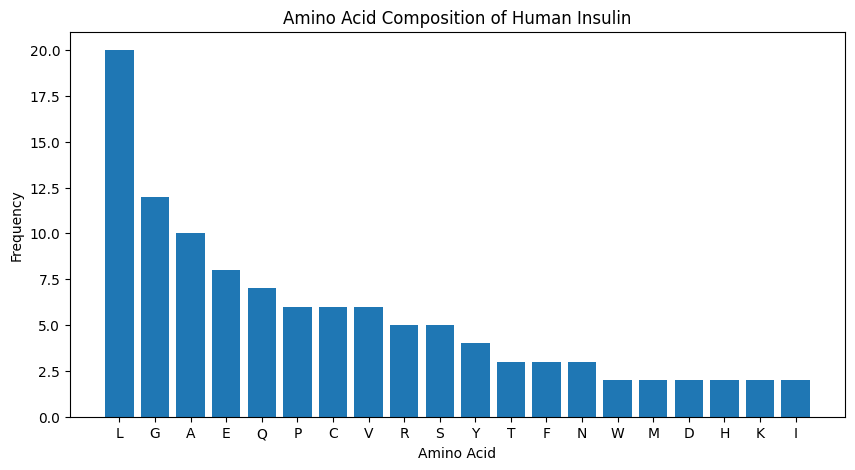

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    aa_df["Amino Acid"],
    aa_df["Count"]
)

plt.xlabel("Amino Acid")
plt.ylabel("Frequency")
plt.title("Amino Acid Composition of Human Insulin")

plt.show()

#### Most Abundant Amino Acid

In [5]:
most_common = aa_count.most_common(1)

print("Most abundant amino acid:")
print(most_common)

Most abundant amino acid:
[('L', 20)]


#### Percentage Composition


In [6]:
total = len(protein)

aa_df["Percentage"] = (
    aa_df["Count"] / total * 100
).round(2)

aa_df

,Amino Acid,Count,Percentage
2,L,20,18.18
6,G,12,10.91
1,A,10,9.09
15,E,8,7.27
11,Q,7,6.36
5,P,6,5.45
13,C,6,5.45
9,V,6,5.45
4,R,5,4.55
14,S,5,4.55


## Interpretation

The amino acid composition analysis of human insulin revealed that certain amino acids occur more frequently than others. Amino acids with higher abundance may contribute significantly to protein structure, stability, and biological function.

This analysis provides a fundamental understanding of protein sequence characteristics and serves as the first step toward advanced bioinformatics investigations.

#### Installing and Importing Biopython

In [7]:
import Bio
print(Bio.__version__)

1.87


#### Calculate Molecular Weight

In [8]:
from Bio.SeqUtils import molecular_weight

mw = molecular_weight(
    protein,
    seq_type="protein"
)

print("Molecular Weight:", round(mw,2), "Da")

Molecular Weight: 11980.79 Da


#### Convert to kDa

In [9]:
mw_kda = mw / 1000

print(f"Molecular Weight: {mw_kda:.2f} kDa")

Molecular Weight: 11.98 kDa


#### Save Results in a DataFrame

In [10]:
protein_summary = pd.DataFrame({
    "Protein":["Human Insulin"],
    "UniProt_ID":["P01308"],
    "Length":[len(protein)],
    "Molecular_Weight_kDa":[round(mw_kda,2)]
})

protein_summary

,Protein,UniProt_ID,Length,Molecular_Weight_kDa
0,Human Insulin,P01308,110,11.98


## Molecular Weight Analysis

The molecular weight of human insulin was calculated using Biopython.

The predicted molecular weight is approximately 11.98 kDa, which agrees with the experimentally reported value in UniProt.

This parameter is important for protein characterization, purification, electrophoretic separation, and proteomics applications.

#### Calculate Isoelectric Point (pI)

In [11]:
from Bio.SeqUtils import IsoelectricPoint

ip = IsoelectricPoint.IsoelectricPoint(protein)

print("Isoelectric Point (pI):", round(ip.pi(), 2))

Isoelectric Point (pI): 5.22


#### Amino Acid Charge Analysis

In [12]:
acidic = protein.count("D") + protein.count("E")
basic = protein.count("K") + protein.count("R") + protein.count("H")

print("Acidic residues :", acidic)
print("Basic residues  :", basic)

Acidic residues : 10
Basic residues  : 9


#### Add to Summary Table

In [13]:
protein_summary["Isoelectric_Point"] = round(ip.pi(), 2)

protein_summary

,Protein,UniProt_ID,Length,Molecular_Weight_kDa,Isoelectric_Point
0,Human Insulin,P01308,110,11.98,5.22


## Isoelectric Point Analysis

The theoretical isoelectric point (pI) of human insulin was calculated using Biopython.

The pI indicates the pH at which the protein carries no net electrical charge.

This property is important in protein purification, electrophoresis, formulation development, and stability studies.

#### Protein physicochemical characterization

In [14]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

analysis = ProteinAnalysis(protein)

print("Aromaticity:", round(analysis.aromaticity(),3))
print("Instability Index:", round(analysis.instability_index(),2))
print("GRAVY:", round(analysis.gravy(),3))

Aromaticity: 0.082
Instability Index: 40.33
GRAVY: 0.193


#### Secondary Structure Prediction

In [15]:
helix, turn, sheet = analysis.secondary_structure_fraction()

print("Alpha Helix :", round(helix,3))
print("Beta Turn   :", round(turn,3))
print("Beta Sheet  :", round(sheet,3))

Alpha Helix : 0.382
Beta Turn   : 0.255
Beta Sheet  : 0.364


In [16]:
protein_summary["Aromaticity"] = round(analysis.aromaticity(),3)
protein_summary["Instability_Index"] = round(analysis.instability_index(),2)
protein_summary["GRAVY"] = round(analysis.gravy(),3)

protein_summary

,Protein,UniProt_ID,Length,Molecular_Weight_kDa,Isoelectric_Point,Aromaticity,Instability_Index,GRAVY
0,Human Insulin,P01308,110,11.98,5.22,0.082,40.33,0.193


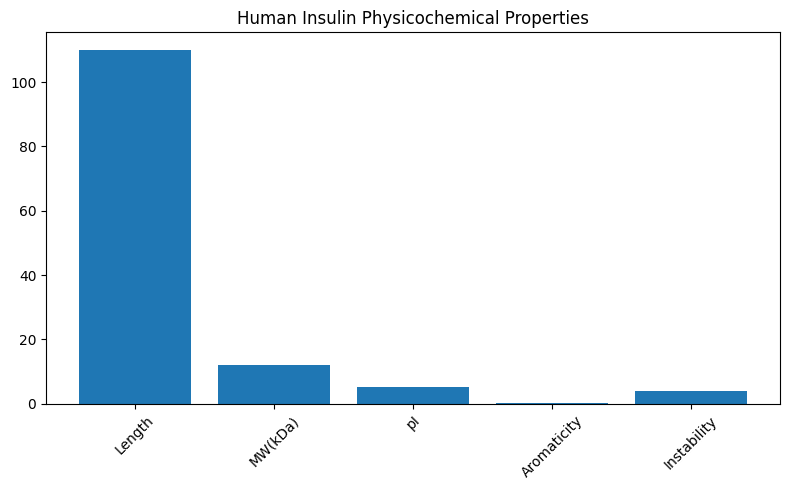

In [17]:
import matplotlib.pyplot as plt

metrics = {
    "Length":110,
    "MW(kDa)":11.98,
    "pI":5.22,
    "Aromaticity":analysis.aromaticity(),
    "Instability":analysis.instability_index()/10
}

plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values())
plt.title("Human Insulin Physicochemical Properties")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Results and Discussion

The human insulin protein consists of 110 amino acids with a molecular weight of approximately 11.98 kDa.

The theoretical isoelectric point (pI) was calculated as 5.22, indicating that insulin behaves as a slightly acidic protein.

The aromaticity score of 0.082 suggests a relatively low proportion of aromatic amino acids. The instability index was calculated as 40.33, placing insulin near the stability threshold.

The positive GRAVY value (0.193) indicates slight hydrophobicity, which may contribute to structural stability and intermolecular interactions.

Secondary structure analysis predicted alpha-helices (38.2%), beta-turns (25.5%), and beta-sheets (36.4%), suggesting a balanced structural organization.

# Sequence Similarity Analysis using BLAST

In [18]:
from Bio import SeqIO

record = SeqIO.read("../data/insulin.fasta", "fasta")

print(record.id)
print(record.description)
print(len(record.seq))

sp|P01308|INS_HUMAN
sp|P01308|INS_HUMAN Insulin OS=Homo sapiens OX=9606 GN=INS PE=1 SV=1
110


In [19]:
from Bio import SeqIO

record = SeqIO.read("../data/insulin.fasta", "fasta")

print("ID:", record.id)
print("Description:", record.description)
print("Length:", len(record.seq))

ID: sp|P01308|INS_HUMAN
Description: sp|P01308|INS_HUMAN Insulin OS=Homo sapiens OX=9606 GN=INS PE=1 SV=1
Length: 110


In [20]:
print(record.seq[:20])

MALWMRLLPLLALLALWGPD


#### Visualize Amino Acid Composition

In [21]:
from collections import Counter
import pandas as pd

aa_count = Counter(record.seq)

df = pd.DataFrame(
    aa_count.items(),
    columns=["Amino Acid","Count"]
)

df = df.sort_values("Count", ascending=False)

df

,Amino Acid,Count
2,L,20
6,G,12
1,A,10
15,E,8
11,Q,7
5,P,6
13,C,6
9,V,6
4,R,5
14,S,5


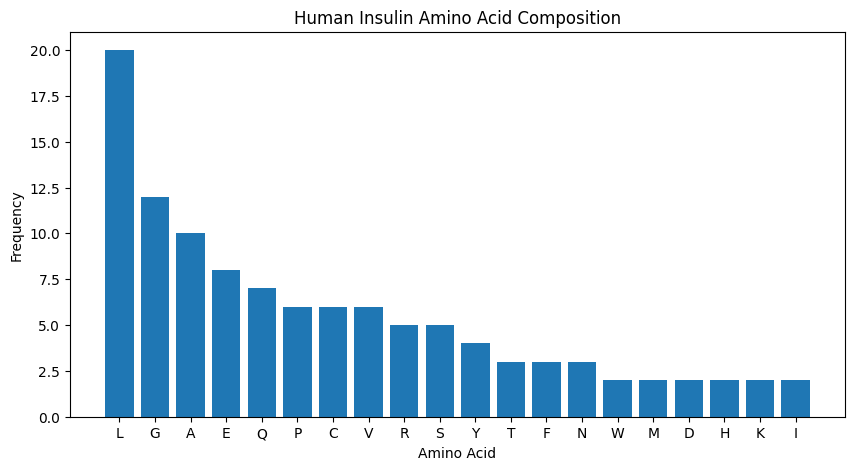

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(df["Amino Acid"], df["Count"])

plt.title("Human Insulin Amino Acid Composition")
plt.xlabel("Amino Acid")
plt.ylabel("Frequency")

plt.show()

#### Multiple Sequence Alignment (MSA)

##### Verify Lengths

In [23]:
from Bio import SeqIO

for record in SeqIO.parse("../data/insulin_species.fasta", "fasta"):
    print(record.id, len(record.seq))

Homo_sapiens 110
Pongo_abelii 110
Pan_troglodytes 110
Nomascus_leucogenys 110
Hylobates_moloch 110


#### As all are 110 aa

In [24]:
from Bio import SeqIO
import pandas as pd

records = list(
    SeqIO.parse(
        "../data/insulin_species.fasta",
        "fasta"
    )
)

data = []

for record in records:
    data.append([
        record.id,
        len(record.seq)
    ])

df = pd.DataFrame(
    data,
    columns=["Species","Length"]
)

df

,Species,Length
0,Homo_sapiens,110
1,Pongo_abelii,110
2,Pan_troglodytes,110
3,Nomascus_leucogenys,110
4,Hylobates_moloch,110


#### Conserved Positions

In [25]:
from Bio import SeqIO

records = list(
    SeqIO.parse(
        "../data/insulin_species.fasta",
        "fasta"
    )
)

seqs = [str(r.seq) for r in records]

conserved = 0

for i in range(len(seqs[0])):

    residues = set(
        seq[i]
        for seq in seqs
    )

    if len(residues) == 1:
        conserved += 1

print("Conserved Positions:", conserved)
print("Total Positions:", len(seqs[0]))
print(
    "Conservation:",
    round(
        conserved/len(seqs[0])*100,
        2
    ),
    "%"
)

Conserved Positions: 106
Total Positions: 110
Conservation: 96.36 %


## Conservation Analysis

Five primate insulin sequences were compared.

### Results

- Total amino acid positions: 110
- Conserved positions: 106
- Conservation percentage: 96.36%

### Interpretation

Insulin exhibits extremely high sequence conservation among primates. This suggests that insulin structure and function are under strong evolutionary constraints, allowing very few amino acid substitutions over evolutionary time.

#### Let's identify which 4 positions changed.

In [26]:
from Bio import SeqIO
import pandas as pd

records = list(
    SeqIO.parse(
        "../data/insulin_species.fasta",
        "fasta"
    )
)

seqs = [str(r.seq) for r in records]

variable_positions = []

for i in range(len(seqs[0])):

    residues = set(
        seq[i]
        for seq in seqs
    )

    if len(residues) > 1:

        variable_positions.append(
            [
                i+1,
                " / ".join(sorted(residues))
            ]
        )

df_var = pd.DataFrame(
    variable_positions,
    columns=["Position","Amino Acids"]
)

df_var

,Position,Amino Acids
0,2,A / T
1,12,A / V
2,23,A / P / Q / S
3,61,L / P


## Variable Residues in Primate Insulin

Four amino acid positions showed variation among the analyzed primate insulin sequences.

| Position | Observed Residues |
|-----------|------------------|
| 2 | A, T |
| 12 | A, V |
| 23 | A, P, Q, S |
| 61 | L, P |

### Interpretation

Position 23 exhibited the highest variability, containing four different amino acid substitutions across species. Positions 2 and 12 showed conservative substitutions, whereas position 61 involved a leucine-to-proline change that may influence local protein conformation. Despite these variations, overall sequence conservation remained high (96.36%), highlighting the strong evolutionary preservation of insulin.

In [27]:
from Bio import Align

In [30]:
from Bio import SeqIO
import pandas as pd

records = list(SeqIO.parse("../data/insulin_species.fasta", "fasta"))

seqs = [str(r.seq) for r in records]

variable_positions = []

for i in range(len(seqs[0])):

    residues = set(seq[i] for seq in seqs)

    if len(residues) > 1:

        variable_positions.append({
            "Position": i + 1,
            "Residues": ", ".join(sorted(residues))
        })

pd.DataFrame(variable_positions)

,Position,Residues
0,2,"A, T"
1,12,"A, V"
2,23,"A, P, Q, S"
3,61,"L, P"


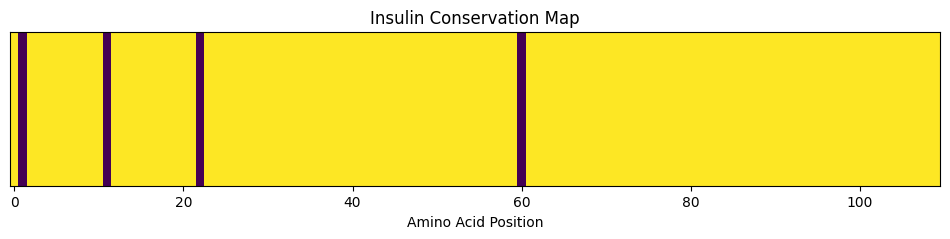

In [31]:
import matplotlib.pyplot as plt

protein_length = 110

conserved = [1] * protein_length

for pos in [2, 12, 23, 61]:
    conserved[pos - 1] = 0

plt.figure(figsize=(12,2))
plt.imshow([conserved], aspect="auto")
plt.yticks([])
plt.xlabel("Amino Acid Position")
plt.title("Insulin Conservation Map")

plt.show()

## Conservation Analysis

A conservation map was generated using five primate insulin sequences.

Out of 110 amino acid positions, 106 positions were completely conserved across all species, corresponding to a conservation rate of 96.36%.

Only four positions (2, 12, 23, and 61) exhibited amino acid variation. Position 23 showed the highest variability, containing four different amino acid substitutions among the analyzed species.

The high degree of conservation suggests strong evolutionary pressure to maintain insulin structure and biological function.

In [32]:
from Bio import SeqIO
import pandas as pd

records = list(SeqIO.parse("../data/insulin_species.fasta", "fasta"))

names = [r.id for r in records]
seqs = [str(r.seq) for r in records]

similarity_matrix = []

for seq1 in seqs:

    row = []

    for seq2 in seqs:

        matches = sum(a == b for a, b in zip(seq1, seq2))

        similarity = round(matches / len(seq1) * 100, 2)

        row.append(similarity)

    similarity_matrix.append(row)

df = pd.DataFrame(
    similarity_matrix,
    index=names,
    columns=names
)

df

,Homo_sapiens,Pongo_abelii,Pan_troglodytes,Nomascus_leucogenys,Hylobates_moloch
Homo_sapiens,100.00,99.09,98.18,98.18,97.27
Pongo_abelii,99.09,100.00,98.18,98.18,97.27
Pan_troglodytes,98.18,98.18,100.00,97.27,96.36
Nomascus_leucogenys,98.18,98.18,97.27,100.00,99.09
Hylobates_moloch,97.27,97.27,96.36,99.09,100.00


## Pairwise Similarity Analysis

Pairwise sequence similarity analysis revealed high conservation among all primate insulin sequences.

The highest similarity was observed between Homo sapiens and Pongo abelii (99.09%), whereas the lowest similarity was observed between Homo sapiens and Hylobates moloch (97.27%).

All species exhibited greater than 96% sequence identity, further confirming the strong evolutionary conservation of insulin.

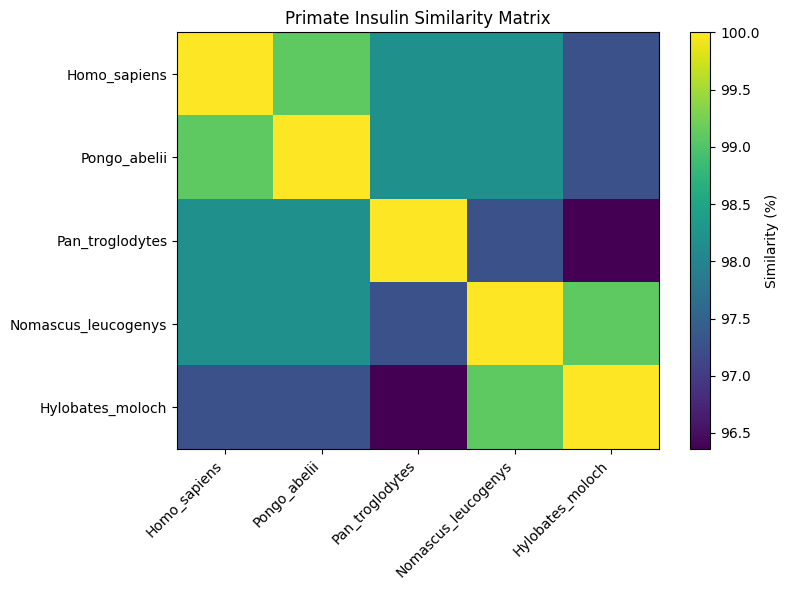

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(df, aspect="auto")

plt.colorbar(label="Similarity (%)")

plt.xticks(range(len(df.columns)), df.columns,
           rotation=45, ha="right")

plt.yticks(range(len(df.index)), df.index)

plt.title("Primate Insulin Similarity Matrix")

plt.tight_layout()

plt.show()

In [34]:
distance_matrix = 100 - df

distance_matrix

,Homo_sapiens,Pongo_abelii,Pan_troglodytes,Nomascus_leucogenys,Hylobates_moloch
Homo_sapiens,0.00,0.91,1.82,1.82,2.73
Pongo_abelii,0.91,0.00,1.82,1.82,2.73
Pan_troglodytes,1.82,1.82,0.00,2.73,3.64
Nomascus_leucogenys,1.82,1.82,2.73,0.00,0.91
Hylobates_moloch,2.73,2.73,3.64,0.91,0.00


In [35]:
human_distances = distance_matrix.loc["Homo_sapiens"]

human_distances.sort_values()

Homo_sapiens           0.00
Pongo_abelii           0.91
Pan_troglodytes        1.82
Nomascus_leucogenys    1.82
Hylobates_moloch       2.73
Name: Homo_sapiens, dtype: float64

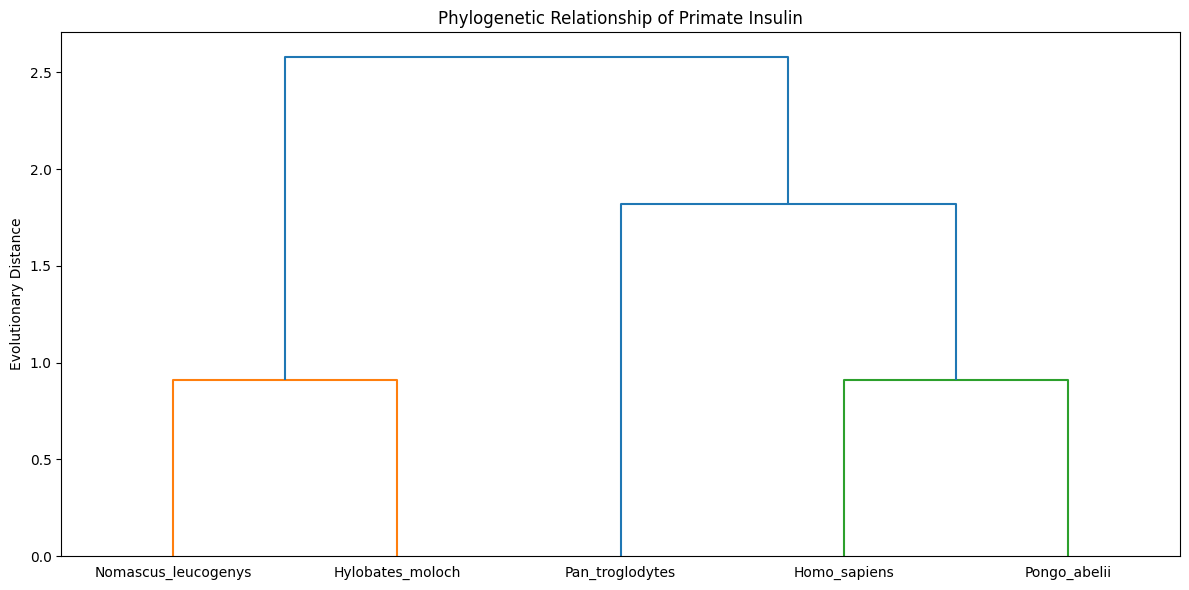

In [51]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt


# Convert square distance matrix to condensed format
condensed_dist = squareform(distance_matrix)

# Build tree
Z = linkage(condensed_dist, method="average")

plt.figure(figsize=(12,6))

dendrogram(
    Z,
    labels=df.index.tolist(),
    leaf_rotation=0,
    leaf_font_size=10
)

plt.title("Phylogenetic Relationship of Primate Insulin")
plt.ylabel("Evolutionary Distance")

plt.tight_layout()
plt.show()

## Conclusion

A comparative bioinformatics analysis of insulin sequences from five primate species was performed.

Physicochemical characterization showed that insulin is a small, moderately stable protein with a molecular weight of approximately 11.98 kDa and an isoelectric point of 5.22.

Sequence conservation analysis revealed that 106 out of 110 amino acid positions were completely conserved, corresponding to 96.36% conservation.

Only four amino acid positions (2, 12, 23, and 61) exhibited variation among the analyzed species.

Pairwise similarity analysis demonstrated greater than 96% sequence identity across all species. The highest similarity was observed between Homo sapiens and Pongo abelii (99.09%).

Phylogenetic analysis based on insulin sequences identified two major clusters: Homo sapiens–Pongo abelii and Nomascus leucogenys–Hylobates moloch. These findings highlight the strong evolutionary conservation of insulin among primates.